In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Cargar el archivo CSV
data = pd.read_csv('TrafficGrid-mode analisis-table.csv', skiprows=6)

# Limpiar los corchetes en la primera fila
data.columns = data.columns.str.replace('[\[\]]', '', regex=True)
data

,run number,grid-size-y,power?,grid-size-x,current-phase,num-cars,speed-limit,semaforos-mode,ticks-per-cycle,current-auto?,step,num-cars-stopped,mean speed of turtles,mean wait-time of turtles
0,3,4,True,4,0,200,0.8,aleatorio,20,True,0,200,0.029700,1.000
1,1,4,True,4,0,200,0.8,aleatorio,20,True,0,200,0.024750,1.000
2,4,4,True,4,0,200,0.8,aleatorio,20,True,0,200,0.029205,1.000
3,2,4,True,4,0,200,0.8,aleatorio,20,True,0,200,0.027225,1.000
4,1,4,True,4,0,200,0.8,aleatorio,20,True,100,191,0.026355,65.095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361795,1799,10,False,10,0,200,0.8,coordinados,100,True,19600,200,0.000000,19255.800
361796,1799,10,False,10,0,200,0.8,coordinados,100,True,19700,200,0.000000,19355.800
361797,1799,10,False,10,0,200,0.8,coordinados,100,True,19800,200,0.000000,19455.800
361798,1799,10,False,10,0,200,0.8,coordinados,100,True,19900,200,0.000000,19555.800


In [4]:
# Calcular el tamaño del grid combinando grid-size-x y grid-size-y
data['grid-size'] = data['grid-size-x'] * data['grid-size-y']

# Agrupar por tamaño del grid y calcular las medias
aggregated_data = data.groupby('grid-size').agg({
    'mean wait-time of turtles': 'mean',
    'mean speed of turtles': 'mean'
}).reset_index()

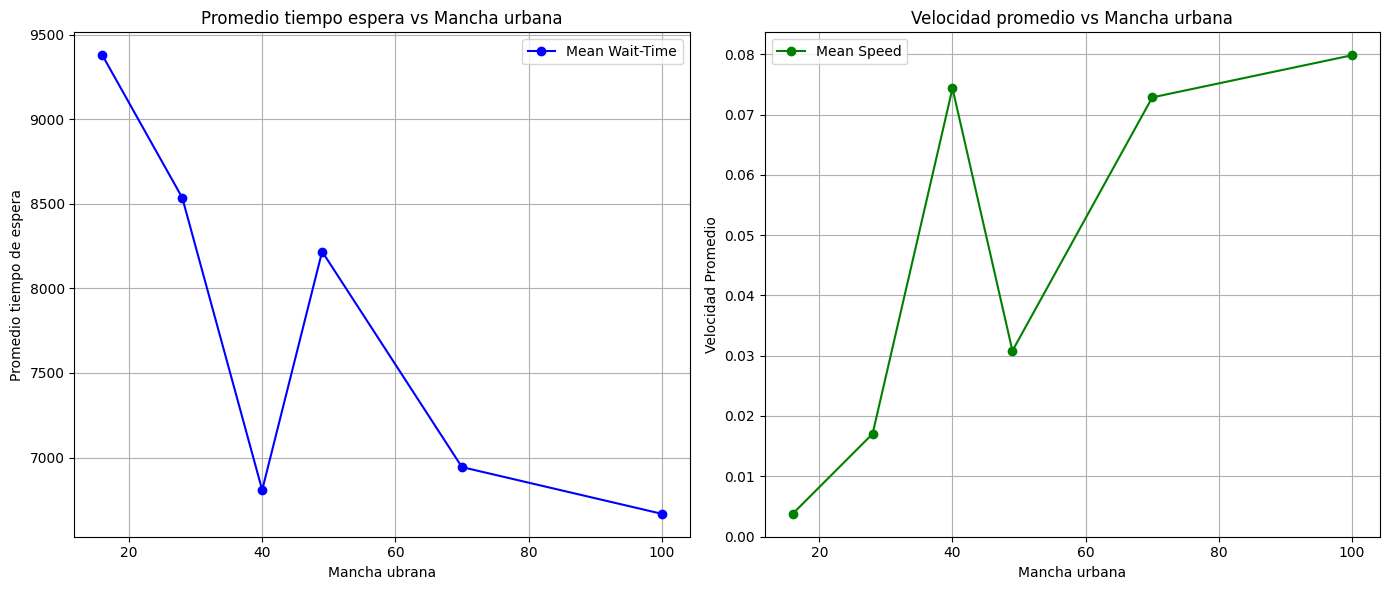

In [5]:
# Crear gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# Gráfico 1: Promedio de tiempo de espera vs tamaño del grid
axes[0].plot(aggregated_data['grid-size'], aggregated_data['mean wait-time of turtles'], marker='o', label='Mean Wait-Time', color='blue')
axes[0].set_title('Promedio tiempo espera vs Mancha urbana')
axes[0].set_xlabel('Mancha ubrana')
axes[0].set_ylabel('Promedio tiempo de espera')
axes[0].grid(True)
axes[0].legend()

# Gráfico 2: Velocidad promedio vs tamaño del grid
axes[1].plot(aggregated_data['grid-size'], aggregated_data['mean speed of turtles'], marker='o', label='Mean Speed', color='green')
axes[1].set_title('Velocidad promedio vs Mancha urbana')
axes[1].set_xlabel('Mancha urbana')
axes[1].set_ylabel('Velocidad Promedio')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


In [6]:
# Agrupar los datos por modo de semáforo y calcular las medias
semaforo_data = data.groupby('semaforos-mode').agg({
    'mean wait-time of turtles': 'mean',
    'mean speed of turtles': 'mean'
}).reset_index()


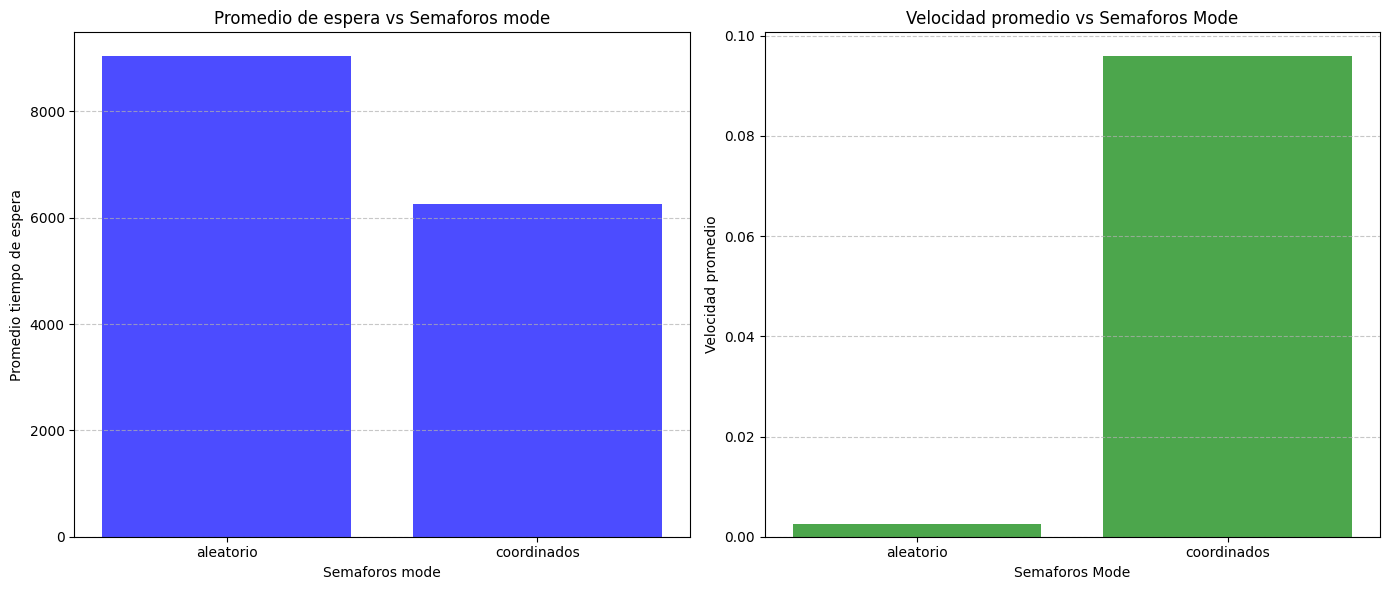

In [7]:
# Crear gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Promedio de tiempo de espera vs modo de semáforo
axes[0].bar(semaforo_data['semaforos-mode'], semaforo_data['mean wait-time of turtles'], color='blue', alpha=0.7)
axes[0].set_title('Promedio de espera vs Semaforos mode')
axes[0].set_xlabel('Semaforos mode')
axes[0].set_ylabel('Promedio tiempo de espera')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico 2: Velocidad promedio vs modo de semáforo
axes[1].bar(semaforo_data['semaforos-mode'], semaforo_data['mean speed of turtles'], color='green', alpha=0.7)
axes[1].set_title('Velocidad promedio vs Semaforos Mode')
axes[1].set_xlabel('Semaforos Mode')
axes[1].set_ylabel('Velocidad promedio')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [8]:
# Agrupar los datos por presencia de semáforos (power?) y calcular las medias
power_data = data.groupby('power?').agg({
    'mean wait-time of turtles': 'mean',
    'mean speed of turtles': 'mean'
}).reset_index()


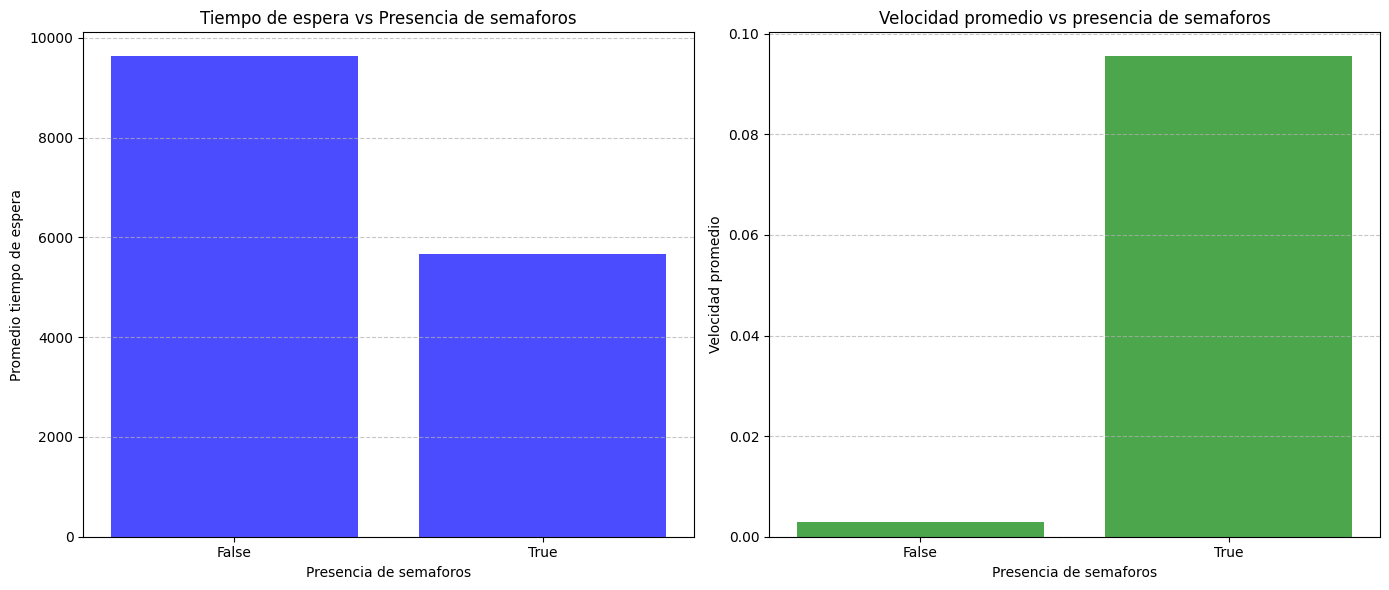

In [9]:
# Crear gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Promedio de tiempo de espera vs presencia de semáforos
axes[0].bar(power_data['power?'].astype(str), power_data['mean wait-time of turtles'], color='blue', alpha=0.7)
axes[0].set_title('Tiempo de espera vs Presencia de semaforos')
axes[0].set_xlabel('Presencia de semaforos')
axes[0].set_ylabel('Promedio tiempo de espera')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico 2: Velocidad promedio vs presencia de semáforos
axes[1].bar(power_data['power?'].astype(str), power_data['mean speed of turtles'], color='green', alpha=0.7)
axes[1].set_title('Velocidad promedio vs presencia de semaforos')
axes[1].set_xlabel('Presencia de semaforos')
axes[1].set_ylabel('Velocidad promedio')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [10]:
# Agrupar los datos por tamaño del grid y presencia de semáforos
grid_power_data = data.groupby(['grid-size', 'power?']).agg({
    'mean wait-time of turtles': 'mean',
    'mean speed of turtles': 'mean'
}).reset_index()

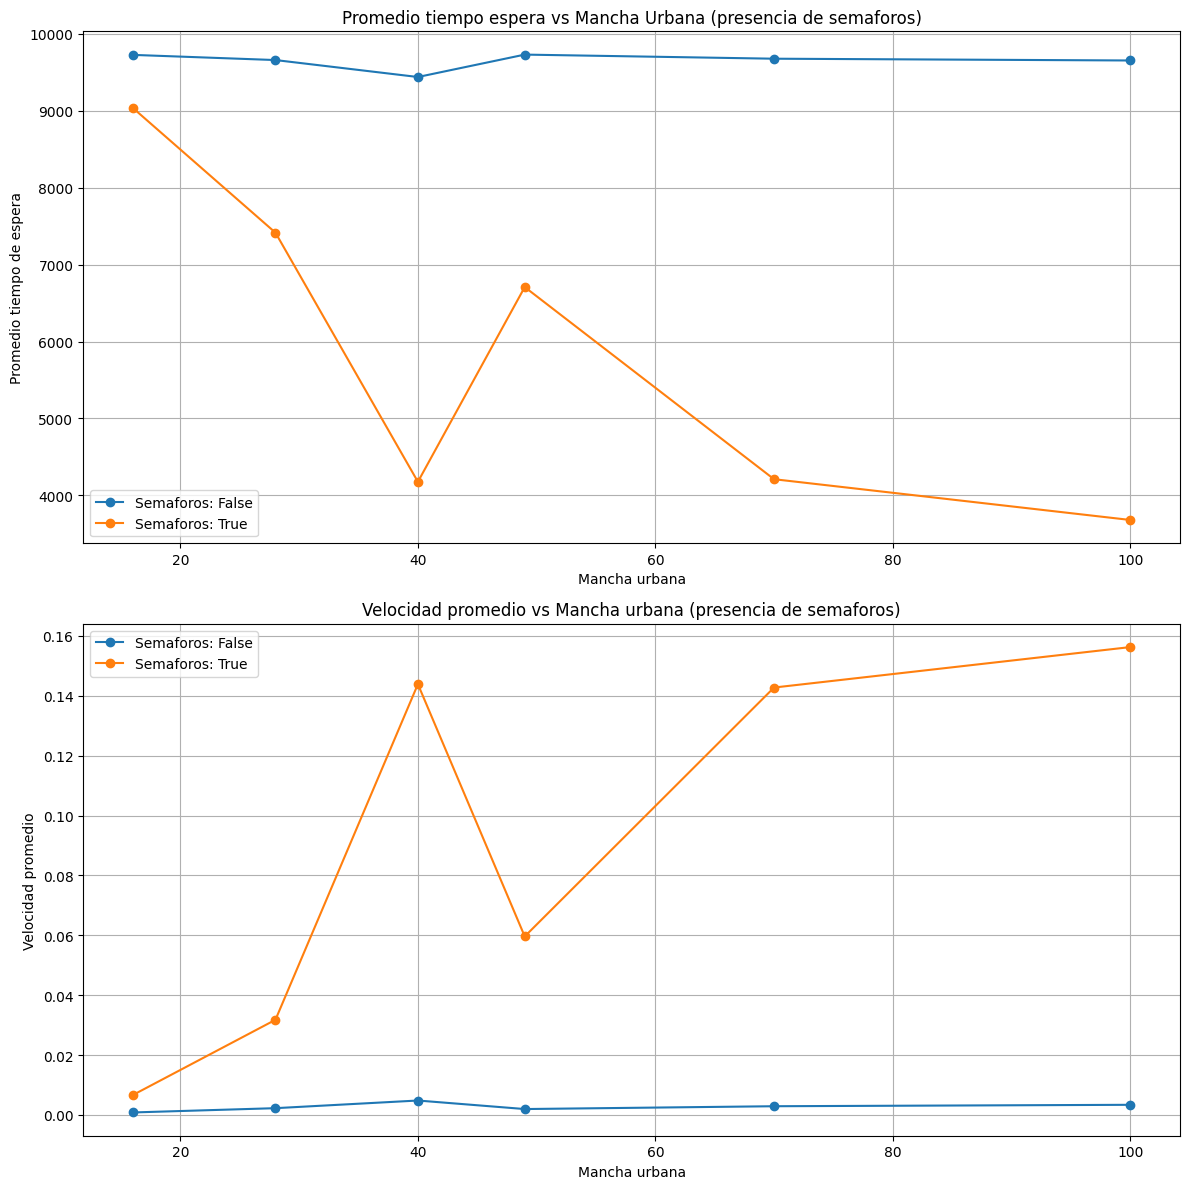

In [11]:
# Crear gráficos
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# Gráfico 1: Promedio de tiempo de espera vs tamaño del grid y presencia de semáforos
for power in grid_power_data['power?'].unique():
    subset = grid_power_data[grid_power_data['power?'] == power]
    axes[0].plot(subset['grid-size'], subset['mean wait-time of turtles'], marker='o', label=f'Semaforos: {power}')

axes[0].set_title('Promedio tiempo espera vs Mancha Urbana (presencia de semaforos)')
axes[0].set_xlabel('Mancha urbana')
axes[0].set_ylabel('Promedio tiempo de espera')
axes[0].grid(True)
axes[0].legend()

# Gráfico 2: Velocidad promedio vs tamaño del grid y presencia de semáforos
for power in grid_power_data['power?'].unique():
    subset = grid_power_data[grid_power_data['power?'] == power]
    axes[1].plot(subset['grid-size'], subset['mean speed of turtles'], marker='o', label=f'Semaforos: {power}')

axes[1].set_title('Velocidad promedio vs Mancha urbana (presencia de semaforos)')
axes[1].set_xlabel('Mancha urbana')
axes[1].set_ylabel('Velocidad promedio')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


In [12]:
# Agrupar por tamaño del grid y presencia de semáforos, luego calcular la media de autos detenidos
stopped_cars_grid_power = data.groupby(['grid-size', 'power?']).agg({
    'num-cars-stopped': 'mean'
}).reset_index()


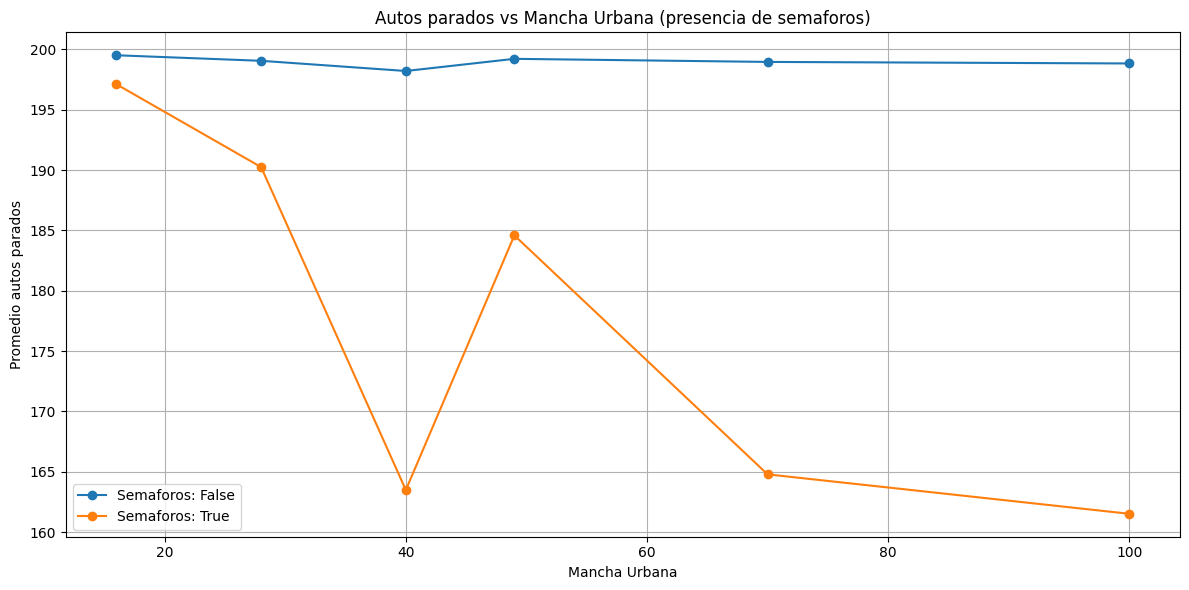

In [13]:
# Crear gráfico
fig, ax = plt.subplots(figsize=(12, 6))

# Graficar los datos
for power in stopped_cars_grid_power['power?'].unique():
    subset = stopped_cars_grid_power[stopped_cars_grid_power['power?'] == power]
    ax.plot(subset['grid-size'], subset['num-cars-stopped'], marker='o', label=f'Semaforos: {power}')

ax.set_title('Autos parados vs Mancha Urbana (presencia de semaforos)')
ax.set_xlabel('Mancha Urbana')
ax.set_ylabel('Promedio autos parados')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()
